In [20]:
from pathlib import Path
Path.cwd()

WindowsPath('D:/Yoobee/Term 3/Capstone/ai-dss-auckland-public-transport/notebooks')

In [21]:
#GTFS Realtime API Call
import requests

# Paste API key here
API_KEY = "c21132ec7641448eb0dac2679444a73a"

# Endpoint
url = "https://api.at.govt.nz/realtime/legacy/tripupdates"

# Headers
headers = {
    "Ocp-Apim-Subscription-Key": API_KEY
}

# Request
response = requests.get(url, headers=headers)

# Output check
print("Status Code:", response.status_code)
print("Content Length:", len(response.content))

Status Code: 200
Content Length: 6082


In [3]:
from datetime import datetime
import os

# Create folder if not exists
save_dir = "data/raw/gtfs_realtime"
os.makedirs(save_dir, exist_ok=True)

# Timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# File path
file_path = f"{save_dir}/tripupdates_{timestamp}.pb"

# Save file
with open(file_path, "wb") as f:
    f.write(response.content)

print("Saved file:", file_path)

Saved file: data/raw/gtfs_realtime/tripupdates_20260430_214137.pb


In [22]:
#install required library for conversion
!pip install gtfs-realtime-bindings

In [23]:
print("Content-Type:", response.headers.get("Content-Type"))
print("First 200 bytes:")
print(response.content[:200])

Content-Type: application/json; charset=utf-8
First 200 bytes:
b'{"status":"OK","response":{"header":{"timestamp":1777559172.102,"gtfs_realtime_version":"1.0","incrementality":0},"entity":[{"id":"521-93021-40500-1-9bc9d477","trip_update":{"trip":{"trip_id":"521-930'


In [24]:
from datetime import datetime
import json
from pathlib import Path

save_dir = Path("data/raw/gtfs_realtime")
save_dir.mkdir(parents=True, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
json_path = save_dir / f"tripupdates_{timestamp}.json"

with open(json_path, "w", encoding="utf-8") as f:
    json.dump(response.json(), f, indent=2)

print("Saved JSON file:", json_path)

Saved JSON file: data\raw\gtfs_realtime\tripupdates_20260501_022635.json


In [25]:
#load JSON 
import json

file_path = file_path = "../data/raw/gtfs_realtime/tripupdates_20260430_204204.json"

with open(file_path, "r", encoding="utf-8") as f:
    data = json.load(f)

print("Keys:", data.keys())
print("Entity count:", len(data["response"]["entity"]))

Keys: dict_keys(['status', 'response', 'error'])
Entity count: 1288


In [26]:
from pathlib import Path
Path.cwd()

WindowsPath('D:/Yoobee/Term 3/Capstone/ai-dss-auckland-public-transport/notebooks')

In [27]:
#Extract Data (Core Logic)
import pandas as pd
records = []

entities = data["response"]["entity"]

for entity in entities:
    trip_update = entity.get("trip_update", {})
    trip = trip_update.get("trip", {})

    records.append({
        "entity_id": entity.get("id"),
        "trip_id": trip.get("trip_id"),
        "route_id": trip.get("route_id"),
        "direction_id": trip.get("direction_id"),
        "start_time": trip.get("start_time"),
        "start_date": trip.get("start_date"),
        "timestamp": trip_update.get("timestamp"),
        "delay_seconds": trip_update.get("delay"),
        "is_deleted": entity.get("is_deleted")
    })

df_realtime = pd.DataFrame(records)

print("Realtime records:", df_realtime.shape)
df_realtime.head()

Realtime records: (1288, 9)


,entity_id,trip_id,route_id,direction_id,start_time,start_date,timestamp,delay_seconds,is_deleted
0,521-93022-76500-1-23f81938,521-93022-76500-1-23f81938,MTID-241,1,21:15:00,20260430,1777414947,0,False
1,902-98011-82800-1-cdd3d9f0,902-98011-82800-1-cdd3d9f0,MTIA-209,0,23:00:00,20260430,1777482603,0,False
2,902-98011-88200-1-cdd3d9f0,902-98011-88200-1-cdd3d9f0,MTIA-209,0,24:30:00,20260430,1777482612,0,False
3,248-840018-70020-2-6155400-1931d669,248-840018-70020-2-6155400-1931d669,ONE-201,1,19:27:00,20260430,1777535095,-12,False
4,248-840042-80820-2-6167400-d9ff341c,248-840042-80820-2-6167400-d9ff341c,ONE-201,1,22:27:00,20260430,1777484461,0,False


In [28]:
df_realtime["delay_minutes"] = df_realtime["delay_seconds"] / 60

df_realtime[["trip_id", "route_id", "timestamp", "delay_seconds", "delay_minutes"]].head()

,trip_id,route_id,timestamp,delay_seconds,delay_minutes
0,521-93022-76500-1-23f81938,MTID-241,1777414947,0,0.0
1,902-98011-82800-1-cdd3d9f0,MTIA-209,1777482603,0,0.0
2,902-98011-88200-1-cdd3d9f0,MTIA-209,1777482612,0,0.0
3,248-840018-70020-2-6155400-1931d669,ONE-201,1777535095,-12,-0.2
4,248-840042-80820-2-6167400-d9ff341c,ONE-201,1777484461,0,0.0


In [35]:
#Loading GTFS Static (routes)
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().parent
GTFS_STATIC_PATH = PROJECT_ROOT / "data" / "raw" / "gtfs_static"

routes = pd.read_csv(GTFS_STATIC_PATH / "routes.txt")

print("Project root:", PROJECT_ROOT)
print("Routes shape:", routes.shape)
routes.head()

Project root: D:\Yoobee\Term 3\Capstone\ai-dss-auckland-public-transport
Routes shape: (220, 11)


,route_id,agency_id,route_short_name,route_long_name,route_desc,route_type,route_url,route_color,route_text_color,route_sort_order,contract_id
0,101-202,NZB,101,101,NaN,3,NaN,NaN,NaN,NaN,19
1,STH-201,AM,STH,STH,NaN,2,NaN,D52923,FFFFFF,NaN,TRAIN
2,TIRI-240,EXPNZ,TIRI,TIRI,NaN,4,NaN,000000,FFFFFF,NaN,FERRY
3,TMK-202,NZB,TMK,TMK,NaN,3,NaN,007AB8,FFFFFF,NaN,16
4,WEST-201,AM,WEST,WEST,NaN,2,NaN,97C93D,152239,NaN,TRAIN


In [37]:
#Joining Realtime + Static Data#
df_realtime_routes = df_realtime.merge(
    routes[["route_id", "route_short_name", "route_long_name", "route_type"]],
    on="route_id",
    how="left"
)

print("Realtime + Routes shape:", df_realtime_routes.shape)

df_realtime_routes[
    ["trip_id", "route_id", "route_short_name", "route_long_name", "delay_seconds", "route_type", "delay_minutes"]
].head()

Realtime + Routes shape: (1288, 13)


,trip_id,route_id,route_short_name,route_long_name,delay_seconds,route_type,delay_minutes
0,521-93022-76500-1-23f81938,MTID-241,MTID,MTID,0,4.0,0.0
1,902-98011-82800-1-cdd3d9f0,MTIA-209,MTIA,MTIA,0,4.0,0.0
2,902-98011-88200-1-cdd3d9f0,MTIA-209,MTIA,MTIA,0,4.0,0.0
3,248-840018-70020-2-6155400-1931d669,ONE-201,ONE,ONE,-12,2.0,-0.2
4,248-840042-80820-2-6167400-d9ff341c,ONE-201,ONE,ONE,0,2.0,0.0


In [33]:
PROJECT_ROOT = Path.cwd().parent

In [39]:
#check quality of data integration
issing_routes = df_realtime_routes["route_short_name"].isna().sum()

print("Missing route matches:", missing_routes)
print("Match rate:", round((1 - missing_routes / len(df_realtime_routes)) * 100, 2), "%")

Missing route matches: 1
Match rate: 99.92 %


In [40]:
#Calculate Average Delay per Route
route_delay = df_realtime_routes.groupby("route_short_name")["delay_minutes"].mean().sort_values(ascending=False)

route_delay.head(10)

route_short_name
394     10.800000
995     10.516667
39       9.838462
HOBS     9.150000
373      7.300000
114      7.111111
365      6.438889
191      5.625000
352      5.108333
WEST     4.779167
Name: delay_minutes, dtype: float64

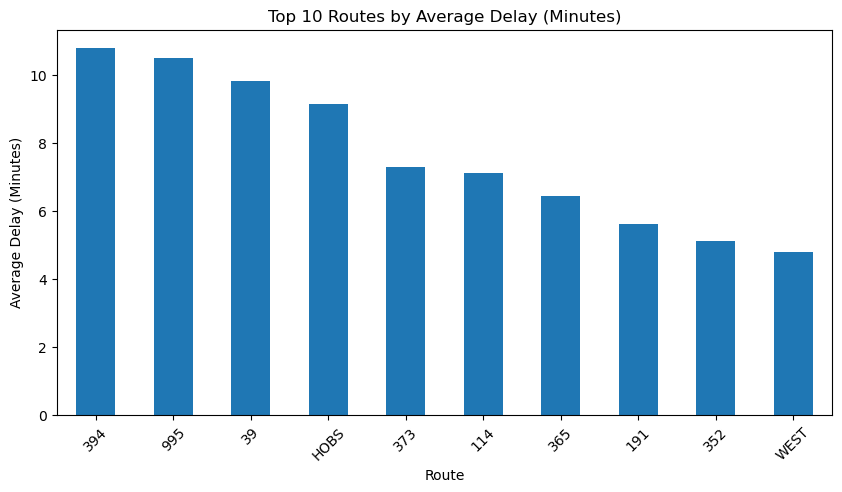

In [41]:
#Most delayed routes visualization
import matplotlib.pyplot as plt

top_delay = route_delay.head(10)

top_delay.plot(kind="bar", figsize=(10,5))

plt.title("Top 10 Routes by Average Delay (Minutes)")
plt.ylabel("Average Delay (Minutes)")
plt.xlabel("Route")
plt.xticks(rotation=45)

plt.show()

In [42]:
#Most Consistently Late Routes
late_ratio = df_realtime_routes.groupby("route_short_name")["delay_minutes"].apply(lambda x: (x > 0).mean())

late_ratio = late_ratio.sort_values(ascending=False)

late_ratio.head(10)

route_short_name
191     1.0
845     1.0
807     1.0
888     1.0
998     1.0
999     1.0
995     1.0
966     1.0
HOBS    1.0
395     1.0
Name: delay_minutes, dtype: float64

In [43]:
df_realtime_routes["route_type"].value_counts()

route_type
3.0    1197
2.0      66
4.0      24
Name: count, dtype: int64

In [44]:
def map_transport(x):
    if x == 3:
        return "Bus"
    elif x == 2:
        return "Train"
    elif x == 4:
        return "Ferry"
    else:
        return "Other"

df_realtime_routes["transport_mode"] = df_realtime_routes["route_type"].apply(map_transport)

df_realtime_routes["transport_mode"].value_counts()

transport_mode
Bus      1197
Train      66
Ferry      24
Other       1
Name: count, dtype: int64

In [45]:
df_realtime_routes.groupby("transport_mode")["delay_minutes"].mean()

transport_mode
Bus     -0.027109
Ferry    0.381250
Other    0.000000
Train    0.802778
Name: delay_minutes, dtype: float64

In [46]:
#add median delay for more robust analysis
df_realtime_routes.groupby("transport_mode")["delay_minutes"].median()

transport_mode
Bus     -0.35
Ferry    0.00
Other    0.00
Train    0.00
Name: delay_minutes, dtype: float64

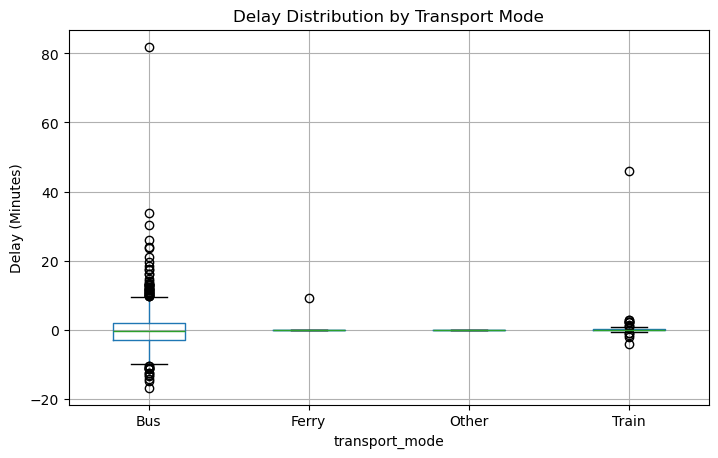

In [47]:
#delay distribution visual
import matplotlib.pyplot as plt

df_realtime_routes.boxplot(column="delay_minutes", by="transport_mode", figsize=(8,5))

plt.title("Delay Distribution by Transport Mode")
plt.suptitle("")
plt.ylabel("Delay (Minutes)")
plt.show()

In [48]:
#save integrated dataset
df_realtime_routes.to_csv("data/interim/realtime_with_routes.csv", index=False)

OSError: Cannot save file into a non-existent directory: 'data\interim'